In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv("../data/processed/iacofi_scored.csv")

# Clean mappings
df['gender_label'] = df['qd1'].map({1:'Male', 0:'Female'})
df['internet_label'] = df['qd14'].map({1:'Has internet', 0:'No internet'})
df['income_label'] = df['qd13'].map({
    1:'Low\n(≤€1,750)', 2:'Mid\n(€1,751–2,900)', 3:'High\n(>€2,900)'})
df['edu_label'] = df['qd9'].map({
    1:'University+', 2:'University+', 3:'University+', 4:'University+',
    5:'High school', 6:'High school',
    7:'Middle or below', 8:'Middle or below',
    9:'Middle or below', 10:'Middle or below'})
df['work_label'] = df['qd10'].map({
    1:'Self-employed', 2:'Employed', 3:'Apprentice',
    4:'Homemaker', 5:'Unemployed', 6:'Retired',
    7:'Unable to work', 8:'Not working', 9:'Student', 10:'Other'})
df['age_group'] = pd.cut(df['qd7'],
    bins=[17,29,39,49,59,69,79],
    labels=['18–29','30–39','40–49','50–59','60–69','70–79'])

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
print("✅ Setup complete")

✅ Setup complete


/tmp/ipykernel_153/4179823904.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gender_label'] = df['qd1'].map({1:'Male', 0:'Female'})
/tmp/ipykernel_153/4179823904.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['internet_label'] = df['qd14'].map({1:'Has internet', 0:'No internet'})
/tmp/ipykernel_153/4179823904.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conc

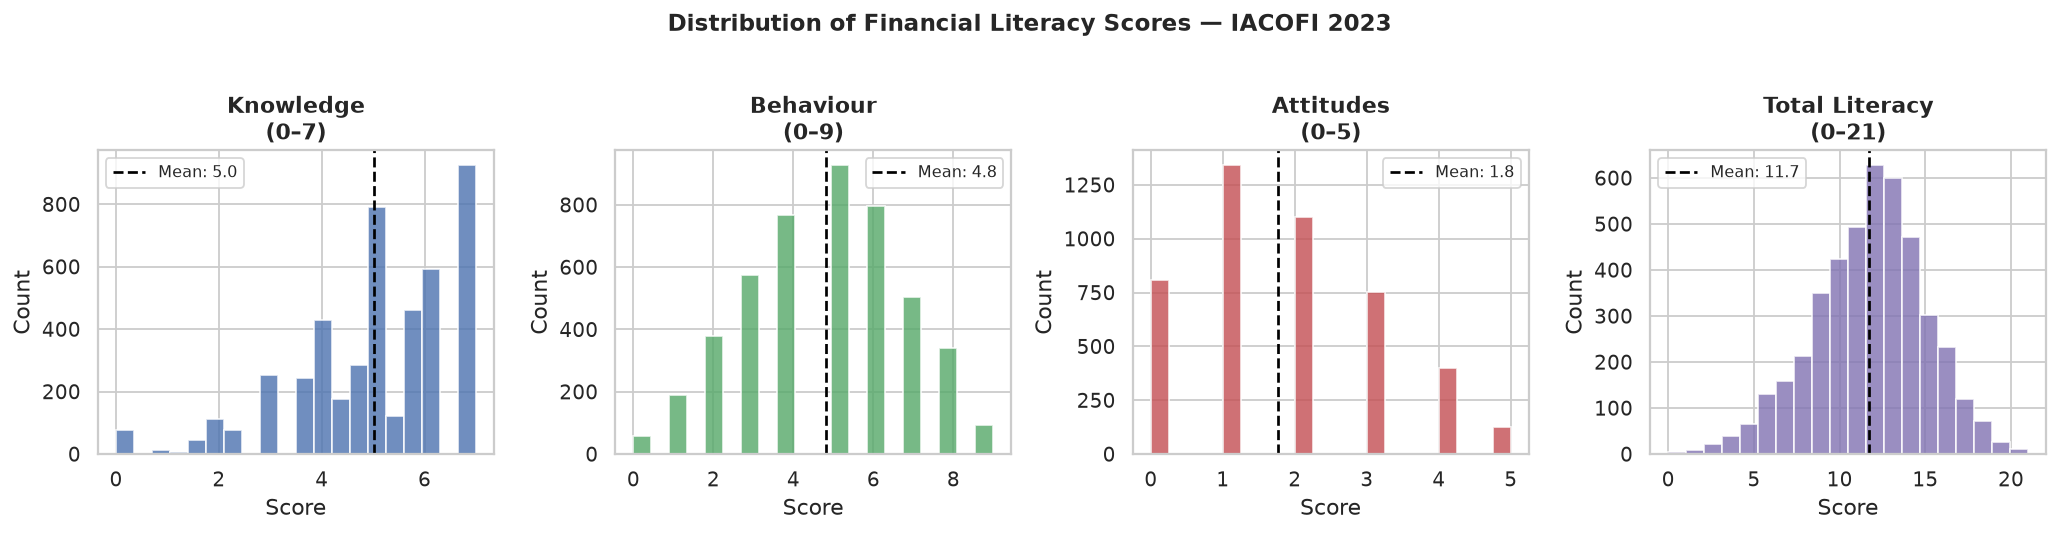

✅ Figure 1 saved


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
scores = ['knowledge_score','behaviour_score','attitudes_score','literacy_score']
titles = ['Knowledge\n(0–7)','Behaviour\n(0–9)','Attitudes\n(0–5)','Total Literacy\n(0–21)']
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']

for ax, col, title, color in zip(axes, scores, titles, colors):
    ax.hist(df[col].dropna(), bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Financial Literacy Scores — IACOFI 2023',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/fig1_score_distributions.png", bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

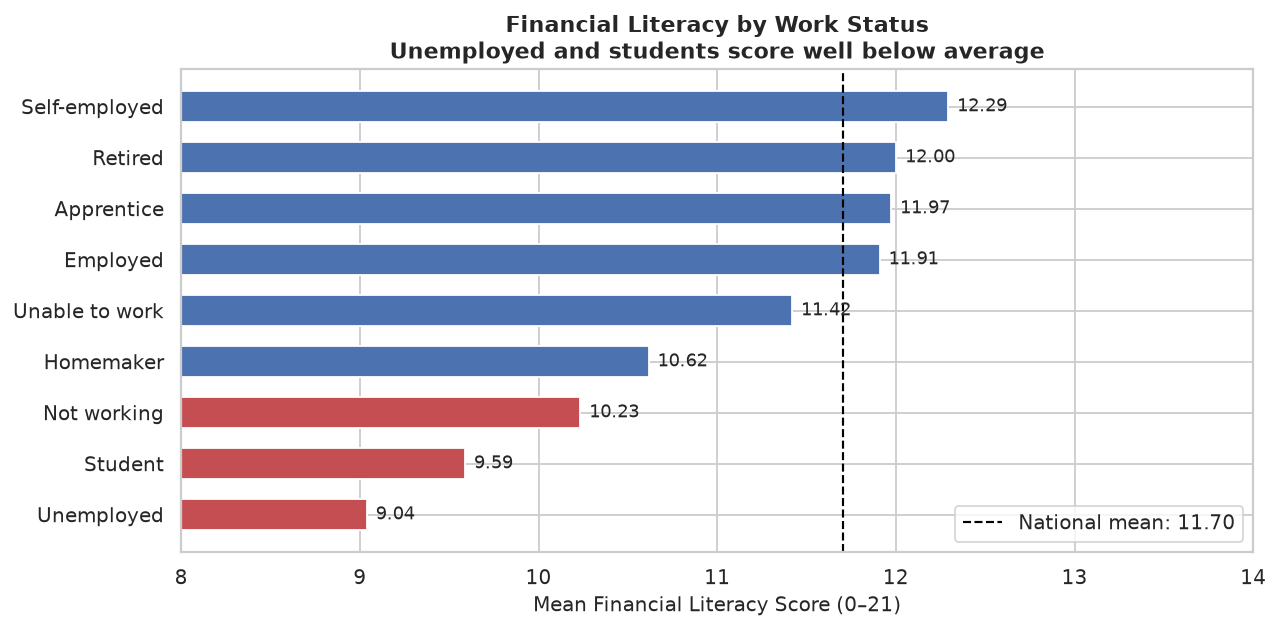

✅ Figure 2 saved


In [3]:
work_order = ['Unemployed','Student','Not working','Homemaker',
              'Unable to work','Employed','Apprentice','Retired','Self-employed']
work_means = (df.groupby('work_label')['literacy_score']
                .mean().reindex(work_order).dropna())

fig, ax = plt.subplots(figsize=(10, 5))
colors_work = ['#C44E52' if x in ['Unemployed','Student','Not working']
               else '#4C72B0' for x in work_means.index]
bars = ax.barh(work_means.index, work_means.values, color=colors_work,
               edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, work_means.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

ax.axvline(df['literacy_score'].mean(), color='black',
           linestyle='--', linewidth=1.2, label=f'National mean: {df["literacy_score"].mean():.2f}')
ax.set_xlabel('Mean Financial Literacy Score (0–21)', fontsize=11)
ax.set_title('Financial Literacy by Work Status\nUnemployed and students score well below average',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlim(8, 14)
plt.tight_layout()
plt.savefig("../data/processed/fig2_work_status.png", bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved")

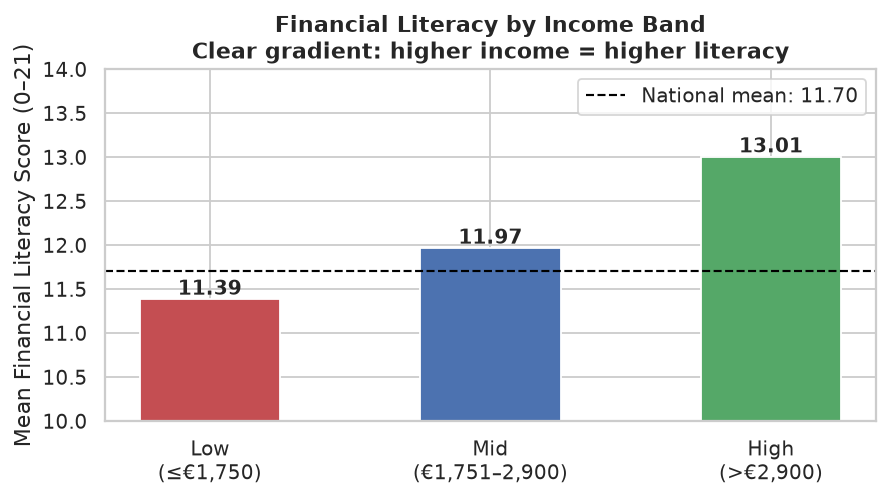

✅ Figure 3 saved


In [4]:
income_order = ['Low\n(≤€1,750)', 'Mid\n(€1,751–2,900)', 'High\n(>€2,900)']
income_means = df.groupby('income_label')['literacy_score'].mean().reindex(income_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(income_means.index, income_means.values,
              color=['#C44E52','#4C72B0','#55A868'],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, income_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(df['literacy_score'].mean(), color='black',
           linestyle='--', linewidth=1.2, label=f'National mean: {df["literacy_score"].mean():.2f}')
ax.set_ylabel('Mean Financial Literacy Score (0–21)')
ax.set_title('Financial Literacy by Income Band\nClear gradient: higher income = higher literacy',
             fontsize=12, fontweight='bold')
ax.set_ylim(10, 14)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig3_income.png", bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")

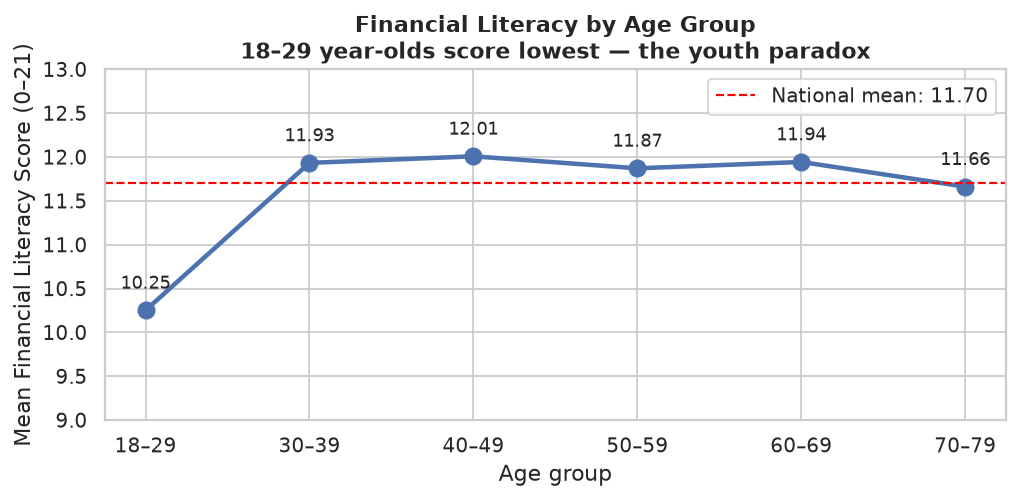

✅ Figure 4 saved


In [5]:
age_means = df.groupby('age_group', observed=True)['literacy_score'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(age_means.index.astype(str), age_means.values,
        marker='o', linewidth=2.5, markersize=9, color='#4C72B0')

for x, y in zip(age_means.index.astype(str), age_means.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10)

ax.axhline(df['literacy_score'].mean(), color='red',
           linestyle='--', linewidth=1.2, label=f'National mean: {df["literacy_score"].mean():.2f}')
ax.set_xlabel('Age group')
ax.set_ylabel('Mean Financial Literacy Score (0–21)')
ax.set_title('Financial Literacy by Age Group\n18–29 year-olds score lowest — the youth paradox',
             fontsize=12, fontweight='bold')
ax.set_ylim(9, 13)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig4_age.png", bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved")

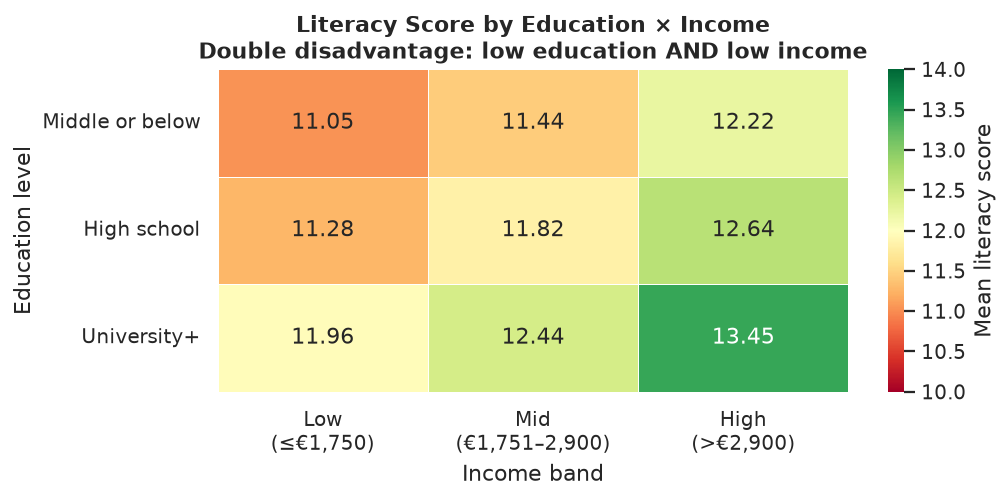

✅ Figure 5 saved


In [6]:
edu_order = ['Middle or below', 'High school', 'University+']
income_order_clean = ['Low\n(≤€1,750)', 'Mid\n(€1,751–2,900)', 'High\n(>€2,900)']

heat = (df.groupby(['edu_label','income_label'])['literacy_score']
          .mean().unstack()
          .reindex(edu_order)[income_order_clean])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=10, vmax=14, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Mean literacy score'})
ax.set_title('Literacy Score by Education × Income\nDouble disadvantage: low education AND low income',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Income band')
ax.set_ylabel('Education level')
plt.tight_layout()
plt.savefig("../data/processed/fig5_edu_income_heatmap.png", bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved")